# Predict google stock price with LSTM

In [1]:
#bibliotecas comuns gráficos e tabelas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rede neural sendo utilizado no LSTM

#!pip install tensorflow


In [2]:
from keras.models import Sequential


2025-08-05 21:51:13.553471: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-05 21:51:13.554176: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-05 21:51:13.556818: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-05 21:51:13.564539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-05 21:51:13.580267: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [3]:
from keras.layers import Dense
from keras.layers import LSTM

In [4]:
# coleta de métrica
# cálculo da acurácia.
from keras import metrics

In [5]:

# normalização dos dados 
from sklearn.preprocessing import MinMaxScaler


In [6]:
df = pd.read_csv('GOOG.csv')
display(df.tail())

,Date,Open,High,Low,Close,Adj Close,Volume
246,2017-12-22,1061.109985,1064.199951,1059.439941,1060.119995,1060.119995,755100
247,2017-12-26,1058.069946,1060.119995,1050.199951,1056.739990,1056.739990,760600
248,2017-12-27,1057.390015,1058.369995,1048.050049,1049.369995,1049.369995,1271900
249,2017-12-28,1051.599976,1054.750000,1044.770020,1048.140015,1048.140015,837100
250,2017-12-29,1046.719971,1049.699951,1044.900024,1046.400024,1046.400024,887500


In [7]:
# comprimento dos dados
L = len(df)
print(f'Comprimento do arquivo GOOG.csv é de {L}')

Comprimento do arquivo GOOG.csv é de 251


input high e low price, forecast close price

In [8]:
#Hi = np.array([df.ix[:,2]])
#Low = np.array([df.ix[:,3]])


# Código corrigido usando .iloc para selecionar a 3ª coluna (índice 2)
Hi = np.array(df.iloc[:, 2])
Low = np.array(df.iloc[:, 3])
Close = np.array(df.iloc[:,4])

In [9]:
Hi[:7]  

array([789.630005, 791.340027, 794.47998 , 807.900024, 809.966003,
       809.130005, 808.150024])

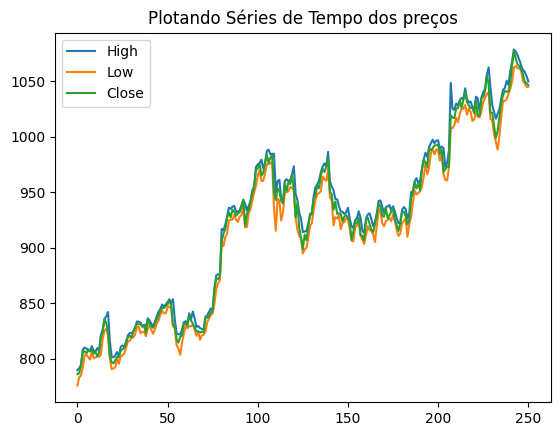

In [10]:
plt.figure(5)

# Corrigido: Passe o array diretamente
H, = plt.plot(Hi, label='High')
L, = plt.plot(Low, label='Low')
C, = plt.plot(Close, label='Close')

plt.title("Plotando Séries de Tempo dos preços")
plt.legend()
plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [11]:
# concatenar em uma linha só
X = np.concatenate([Hi,Low], axis =0)
print(X.shape)
print(X)

(502,)
[ 789.630005  791.340027  794.47998   807.900024  809.966003  809.130005
  808.150024  807.390015  811.223999  807.140015  806.205017  809.47998
  806.909973  820.869995  825.900024  835.77002   838.        841.950012
  815.840027  801.25      801.190002  802.700012  806.        801.669983
  810.5       811.840027  810.659973  815.25      820.958984  823.
  823.        824.400024  828.070007  833.450012  833.25      832.460022
  829.        830.5       828.539978  836.255005  834.51001   831.359985
  828.880005  833.409973  838.150024  842.        844.909973  848.684998
  847.23999   848.630005  850.849976  853.400024  850.219971  853.5
  835.549988  822.570007  821.929993  821.630005  825.98999   832.765015
  833.679993  831.640015  840.849976  835.179993  842.450012  836.390015
  828.484985  829.349976  827.427002  826.659973  826.380005  837.75
  838.929993  842.219971  845.200012  843.880005  863.450012  875.
  876.049988  875.400024  916.849976  915.679993  920.77002   928.

In [12]:
# Corrigido: Use np.vstack para empilhar os arrays verticalmente
X = np.vstack([Hi, Low])

print("Shape do array Hi:", Hi.shape)
print("Shape do array Low:", Low.shape)
print("\nShape do novo array X:", X.shape)
print("\nNovo array X:")
print(X)

Shape do array Hi: (251,)
Shape do array Low: (251,)

Shape do novo array X: (2, 251)

Novo array X:
[[ 789.630005  791.340027  794.47998   807.900024  809.966003  809.130005
   808.150024  807.390015  811.223999  807.140015  806.205017  809.47998
   806.909973  820.869995  825.900024  835.77002   838.        841.950012
   815.840027  801.25      801.190002  802.700012  806.        801.669983
   810.5       811.840027  810.659973  815.25      820.958984  823.
   823.        824.400024  828.070007  833.450012  833.25      832.460022
   829.        830.5       828.539978  836.255005  834.51001   831.359985
   828.880005  833.409973  838.150024  842.        844.909973  848.684998
   847.23999   848.630005  850.849976  853.400024  850.219971  853.5
   835.549988  822.570007  821.929993  821.630005  825.98999   832.765015
   833.679993  831.640015  840.849976  835.179993  842.450012  836.390015
   828.484985  829.349976  827.427002  826.659973  826.380005  837.75
   838.929993  842.219971  

In [13]:
X_trans = np.transpose(X)
print(X_trans[:10])

[[789.630005 775.799988]
 [791.340027 783.159973]
 [794.47998  785.02002 ]
 [807.900024 792.203979]
 [809.966003 802.830017]
 [809.130005 803.51001 ]
 [808.150024 801.369995]
 [807.390015 799.169983]
 [811.223999 806.690002]
 [807.140015 800.369995]]


In [14]:
Y = Close
Y_trans = np.transpose(Y)


In [15]:
Y_trans

array([ 786.140015,  786.900024,  794.02002 ,  806.150024,  806.650024,
        804.789978,  807.909973,  806.359985,  807.880005,  804.609985,
        806.070007,  802.174988,  805.02002 ,  819.309998,  823.869995,
        835.669983,  832.150024,  823.309998,  802.320007,  796.789978,
        795.695007,  798.530029,  801.48999 ,  801.340027,  806.969971,
        808.380005,  809.559998,  813.669983,  819.23999 ,  820.450012,
        818.97998 ,  824.159973,  828.070007,  831.659973,  830.76001 ,
        831.330017,  828.640015,  829.280029,  823.210022,  835.23999 ,
        830.630005,  829.080017,  827.780029,  831.909973,  835.369995,
        838.679993,  843.25    ,  845.539978,  845.619995,  847.200012,
        848.780029,  852.119995,  848.400024,  830.460022,  829.590027,
        817.580017,  814.429993,  819.51001 ,  820.919983,  831.409973,
        831.5     ,  829.559998,  838.549988,  834.570007,  831.409973,
        827.880005,  824.669983,  824.72998 ,  823.349976,  824.

In [16]:
# normalizar
scaler = MinMaxScaler()
scaler.fit(X_trans)
X = scaler.transform(X_trans)

In [17]:
X[:10]

array([[0.        , 0.        ],
       [0.0059199 , 0.0255777 ],
       [0.01679005, 0.03204181],
       [0.0632487 , 0.05700778],
       [0.07040088, 0.09393579],
       [0.06750675, 0.09629893],
       [0.06411417, 0.08886186],
       [0.06148311, 0.0812163 ],
       [0.07475592, 0.10735016],
       [0.06061764, 0.08538663]])

In [22]:
#scaler1 = MinMaxScaler()
#scaler1.fit(Y_trans)
#Y = scaler1.transform(Y_trans)

# Antes de chamar o scaler, remodele o array para 2D
# O reshape(-1, 1) é a solução
Y_trans_reshaped = Y_trans.reshape(-1, 1)

# Agora, o scaler vai funcionar corretamente
scaler1 = MinMaxScaler()
scaler1.fit(Y_trans_reshaped)
Y = scaler1.transform(Y_trans_reshaped)

print("Array original:")
print(Y_trans[:5])
print("\nArray remodelado para 2D:")
print(Y_trans_reshaped[:5])
print("\nResultado após a normalização (Y):")
print(Y[:5])

Array original:
[786.140015 786.900024 794.02002  806.150024 806.650024]

Array remodelado para 2D:
[[786.140015]
 [786.900024]
 [794.02002 ]
 [806.150024]
 [806.650024]]

Resultado após a normalização (Y):
[[0.        ]
 [0.00261171]
 [0.02707905]
 [0.06876292]
 [0.07048113]]


In [23]:
X = np.reshape(X, (X.shape[0],1, X.shape[1]))
print(X.shape)

(251, 1, 2)


In [25]:
print(X[:10])

[[[0.         0.        ]]

 [[0.0059199  0.0255777 ]]

 [[0.01679005 0.03204181]]

 [[0.0632487  0.05700778]]

 [[0.07040088 0.09393579]]

 [[0.06750675 0.09629893]]

 [[0.06411417 0.08886186]]

 [[0.06148311 0.0812163 ]]

 [[0.07475592 0.10735016]]

 [[0.06061764 0.08538663]]]


In [26]:

#Criando model sequencilal
#input_shape=(1,2), é o mesmo do shape, variáveis auxiliadoras, 1, 2


model = Sequential()

Essa linha inicializa um modelo de rede neural. O nome Sequential significa que as camadas da rede serão adicionadas em sequência,

#### Detalhes add:

LSTM significa Long Short-Term Memory. Essa é uma camada especial de rede neural recorrente (RNN) que foi projetada para lidar com dados sequenciais.

100: Este é o número de unidades ou neurônios na camada LSTM. Quanto maior esse número, maior a capacidade do modelo de aprender padrões complexos nos dados.

activation='tanh': A função de ativação tanh é aplicada à saída principal da camada. Ela ajuda a controlar os valores, mantendo-os em um intervalo entre -1 e 1.

input_shape=(1, 2): Esta é uma parte crucial. Ela informa ao modelo o formato dos dados que ele vai receber.

O primeiro valor, 1, é o número de passos de tempo na sua sequência.

O segundo valor, 2, é o número de características ou variáveis em cada passo de tempo.

Neste caso, o modelo está esperando dados organizados como uma sequência com 1 passo de tempo e 2 características.

recurrent_activation='hard_sigmoid': Esta é a função de ativação usada internamente nas portas da célula LSTM (que controlam o fluxo de informações). A hard_sigmoid é uma versão mais rápida da função sigmoide.



In [27]:
# Lstm redes neurais
model = Sequential()
model.add(LSTM(100,activation = 'tanh', input_shape=(1,2), recurrent_activation='hard_sigmoid'))



/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.add(Dense(1)) # modelo com 1 dado de interesse, que é o preço close

#camada neural totalmente conectada (ou Dense) ao seu modelo.
#Dense: Significa que cada neurônio nessa camada está conectado a todos os neurônios da camada anterior.
#1: Indica que essa camada tem apenas um neurônio.

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,301 (161.33 KB)

 Trainable params: 41,301 (161.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#from keras.models import Sequential
#from keras.layers import LSTM, Input

# O shape de entrada (1, 2) agora é definido em uma camada Input
#input_layer = Input(shape=(1, 2))

#model = Sequential()
#model.add(input_layer)

# A camada LSTM não precisa mais do argumento input_shape
#model.add(LSTM(100, activation='tanh', recurrent_activation='hard_sigmoid'))

# Para ver um resumo da estrutura do seu modelo
#model.summary()

Erro Quadrático Médio) => calcula a média do quadrado da diferença entre o valor previsto e o valor real.

O otimizador é o algoritmo que o modelo usará para ajustar seus pesos e bias (os parâmetros internos) com o objetivo de minimizar a função de perda. Pense nele como o "motor" do aprendizado. rmsprop é um algoritmo de otimização popular e eficiente que se adapta bem a diferentes tipos de dados.

mae (Mean Absolute Error, ou Erro Absoluto Médio) é uma métrica que calcula a média da diferença absoluta entre os valores previstos e os reais. 

In [34]:

# acurácia MSE
#model.compile(loss='mean_squared_error', optimizer='rmsprop', metrics = [metrics.mae] )
model.compile(loss='mean_squared_error', optimizer='rmsprop', metrics=['mae'])

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,301 (161.33 KB)

 Trainable params: 41,301 (161.33 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#model.fit(X,Y,epoch=100,batch_size=1,verboe=2)

model.fit(X, Y, epochs=100, batch_size=1, verbose=2)

Epoch 1/100
251/251 - 2s - 6ms/step - loss: 0.0372 - mae: 0.1297
Epoch 2/100
251/251 - 1s - 3ms/step - loss: 4.0152e-04 - mae: 0.0155
Epoch 3/100
251/251 - 1s - 3ms/step - loss: 2.8984e-04 - mae: 0.0135
Epoch 4/100
251/251 - 1s - 3ms/step - loss: 2.8895e-04 - mae: 0.0133
Epoch 5/100
251/251 - 1s - 3ms/step - loss: 3.1329e-04 - mae: 0.0138
Epoch 6/100
251/251 - 1s - 2ms/step - loss: 2.9517e-04 - mae: 0.0134
Epoch 7/100
251/251 - 1s - 3ms/step - loss: 3.0480e-04 - mae: 0.0135
Epoch 8/100
251/251 - 1s - 3ms/step - loss: 2.9625e-04 - mae: 0.0134
Epoch 9/100
251/251 - 1s - 2ms/step - loss: 2.7456e-04 - mae: 0.0125
Epoch 10/100
251/251 - 1s - 2ms/step - loss: 2.8929e-04 - mae: 0.0133
Epoch 11/100
251/251 - 1s - 3ms/step - loss: 2.9201e-04 - mae: 0.0134
Epoch 12/100
251/251 - 1s - 3ms/step - loss: 2.9580e-04 - mae: 0.0131
Epoch 13/100
251/251 - 1s - 2ms/step - loss: 2.8038e-04 - mae: 0.0130
Epoch 14/100
251/251 - 1s - 2ms/step - loss: 2.9741e-04 - mae: 0.0134
Epoch 15/100
251/251 - 1s - 3ms/s

Explicação dos Parâmetros

epochs: Define o número de vezes que o algoritmo de treinamento trabalhará em todo o seu conjunto de dados de treinamento. Um epoch é quando o modelo passa por todos os dados de treinamento uma vez.

batch_size: Define o número de amostras que o modelo usará antes de atualizar os pesos do modelo. No seu caso, batch_size=1 significa que os pesos são atualizados após cada amostra.

verbose: Controla o que é exibido na tela durante o treinamento.

verbose=0: Nenhuma informação é impressa.

verbose=1: Barra de progresso animada.

verbose=2: Imprime a época (epoch) em uma linha.

In [44]:
 # Previsão do preço

In [43]:
Predict = model.predict(X, verbose=1)
print(Predict)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[-0.00151094]
 [ 0.01457296]
 [ 0.02277114]
 [ 0.05650211]
 [ 0.07933596]
 [ 0.0793139 ]
 [ 0.07384337]
 [ 0.06860341]
 [ 0.08843087]
 [ 0.07044211]
 [ 0.07015672]
 [ 0.07668045]
 [ 0.07253435]
 [ 0.09777401]
 [ 0.13176142]
 [ 0.16055554]
 [ 0.16766259]
 [ 0.16145088]
 [ 0.08273175]
 [ 0.04322553]
 [ 0.04436919]
 [ 0.04817154]
 [ 0.06869437]
 [ 0.05259544]
 [ 0.07820854]
 [ 0.0828803 ]
 [ 0.08357331]
 [ 0.1003636 ]
 [ 0.1197907 ]
 [ 0.12388855]
 [ 0.12849967]
 [ 0.13161226]
 [ 0.1422786 ]
 [ 0.16313624]
 [ 0.1633708 ]
 [ 0.15135363]
 [ 0.14847834]
 [ 0.15042192]
 [ 0.14028278]
 [ 0.16543157]
 [ 0.1671968 ]
 [ 0.15503128]
 [ 0.14492364]
 [ 0.15964274]
 [ 0.17686914]
 [ 0.18738288]
 [ 0.20185286]
 [ 0.21478163]
 [ 0.20791836]
 [ 0.21001935]
 [ 0.22357962]
 [ 0.2293929 ]
 [ 0.22075088]
 [ 0.19544195]
 [ 0.1641907 ]
 [ 0.11624458]
 [ 0.10898602]
 [ 0.09825453]
 [ 0.12481619]
 [ 0.15088864]
 [ 0.16471143]
 [ 0.15853623]
 [ 0.17622265]
 [ 0.16710025]
 [

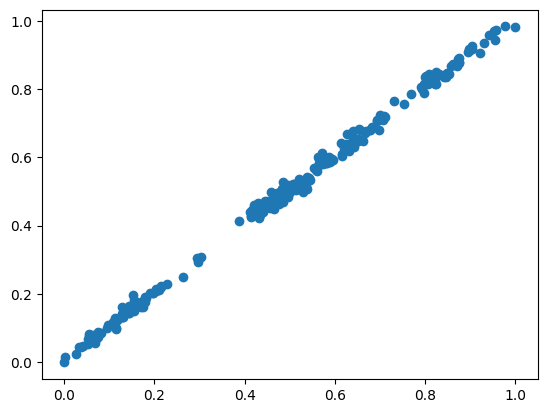

In [45]:
plt.figure(2)
plt.scatter(Y, Predict)
plt.show() # boa acurácia

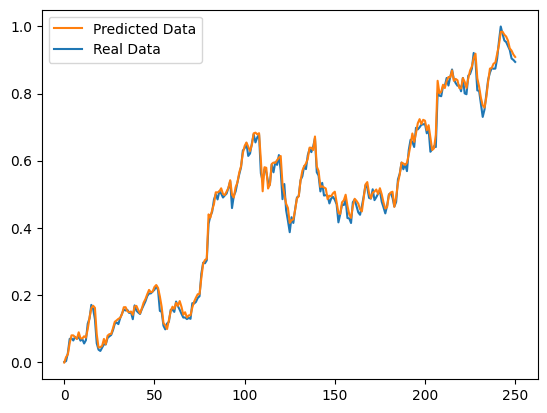

In [46]:
plt.figure(3)
Test, = plt.plot(Y)
Predict, = plt.plot(Predict)
plt.legend([Predict, Test],["Predicted Data", "Real Data"])
plt.show()
